# HiFi Phase 16 — Live 4-Arm Paper-Trading Report

**Status: EXPERIMENT IN PROGRESS — not for performance conclusions yet.**
Paper trading only. Not investment advice. Arms have different inception dates.

| Arm | Strategy | Type |
|---|---|---|
| **A** | parallel ensemble (champion) | LLM |
| **B** | full sequential (herding contrast) | LLM |
| **C** | equal-weight buy-and-hold | null control |
| **D** | riskbudget calm_exposure | deterministic quant |

### Read section 0 first

On 2026-08-14 a data-resolution defect (DJ-120) was found: the MCP tools
globbed a legacy flat parquet layout holding 16 tickers stale since 2023-06-30,
while the canonical nested store held all 98 current to the previous close. For
the first month of live trading **83 of 98 tickers returned `TICKER_NOT_FOUND`
on every pass**, and the agents rendered that absence as conviction — the risk
agent answered `Sell` at confidence 1.0 with the rationale *"decision based
solely on absence of information"*. Macro and sentiment were starved by two
further, independent path bugs.

The consequence is that **every decision-layer statistic before the fix
measures the data layer, not the models**. Section 0 is the gate: if tool
failure rates are non-zero, nothing below it can be read as an AI result.

Layers: **0 Provenance** · **1 Financial** · **2 Tearsheets** ·
**3 Decisions** · **4 Per-stock traceability** · **5 AI-operations**.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
DATA = str(ROOT / "data")
try:
    from dotenv import load_dotenv; load_dotenv(ROOT / ".env")  # LangFuse creds for section 5
except Exception:
    pass

import pandas as pd, matplotlib.pyplot as plt
from hifi.analytics import live_report as lr
from hifi.analytics import decision_audit as da
pd.set_option("display.width", 170); pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.figsize"] = (11, 5)

status = lr.experiment_status(DATA)
print("Repo:", ROOT)
print("Days of data:", status["days_of_data"],
      "| window:", status["first_date"], "->", status["last_date"])
print("Arms live:", status["arms_live"])
print("Live IC:", status["ic_status"])

Repo: /Users/alberto/Documents/projects/HiFi
Days of data: 25 | window: 2026-07-11 -> 2026-08-14
Arms live: ['A', 'B', 'C', 'D']
Live IC: pending — needs 60-day forward labels (Phase 16 E3)


## 0 — Data provenance and agent health

**The gate.** Two questions before any interpretation: did the agents' tools
return data, and did any agent collapse to a constant?

### 0a — Store coverage

`found` must be 98/98, `layout` must be `nested` for all, and `last_date`
should be the previous close. Any `flat-legacy` row is a stale 2023 fixture
shadowing the real store — the DJ-120 defect.

In [2]:
from hifi.data.universe import PHASE14_UNIVERSE
from hifi.data.market_store import coverage_report

tickers = [e["ticker"] for e in PHASE14_UNIVERSE]
cov = pd.DataFrame(coverage_report(tickers, DATA)).T
print(f"tickers found : {int(cov['found'].sum())}/{len(cov)}")
print(f"layouts       : {cov['layout'].value_counts().to_dict()}")
print(f"last_date     : {sorted(cov['last_date'].dropna().unique())[-3:]}")
stale = cov[cov["layout"] == "flat-legacy"]
if len(stale):
    print(f"\n!! {len(stale)} ticker(s) on the stale flat layout: {list(stale.index)}")
else:
    print("\nAll tickers resolve to the canonical nested store.")

tickers found : 98/98
layouts       : {'nested': 98}
last_date     : ['2026-08-13']

All tickers resolve to the canonical nested store.


### 0b — MCP tool-call failure rate per agent, over time

The headline diagnostic. Flat high lines are a broken data path, not a market
view. The DJ-120 fix lands as a cliff to zero; dates left of it are void for
decision-science purposes.

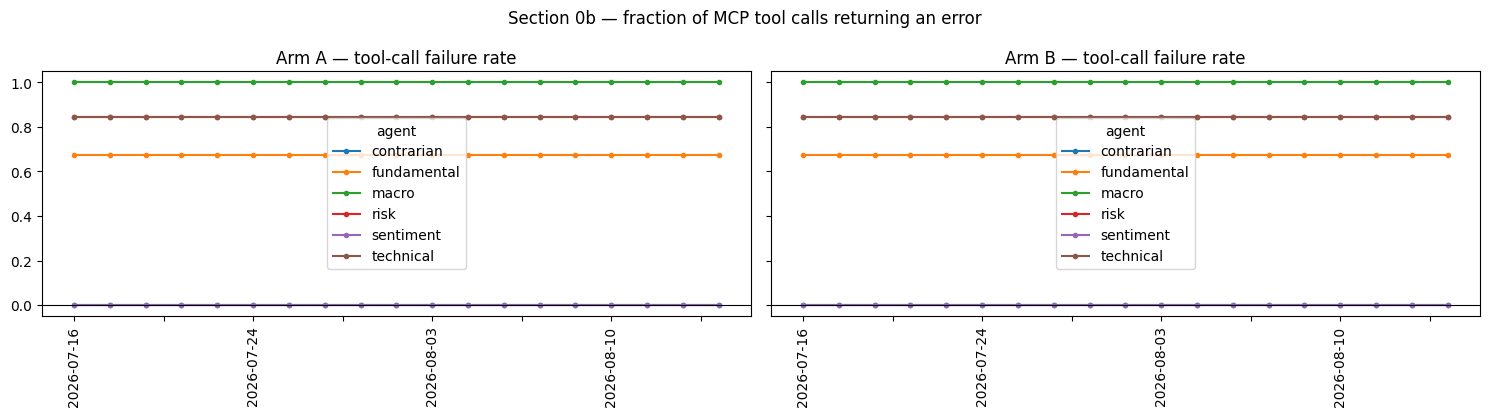

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
for ax, arm in zip(axes, ["A", "B"]):
    pm = da.provenance_matrix(arm, DATA)
    if pm.empty:
        ax.set_title(f"{arm}: no sidecars"); continue
    piv = pm.pivot(index="decision_date", columns="agent", values="failure_rate")
    piv = piv.drop(columns=[c for c in piv.columns if piv[c].isna().all()], errors="ignore")
    piv.plot(ax=ax, marker="o", ms=3)
    ax.set_title(f"Arm {arm} — tool-call failure rate"); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color="k", lw=0.8); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=90)
plt.suptitle("Section 0b — fraction of MCP tool calls returning an error")
plt.tight_layout(); plt.show()

### 0c — Did any agent collapse to a constant?

`when_tools_ok` vs `when_tools_failed` is the decisive split. An agent whose
decision changes completely between those columns is reporting on data
availability, not on the security. A constant member contributes no
information *and* mechanically suppresses measured unanimity, so this must be
clean before any Page-theorem claim is read off section 3.

In [4]:
for arm in ["A", "B"]:
    beh = da.agent_behaviour(arm, DATA)
    if beh.empty:
        print(f"Arm {arm}: no sidecars yet."); continue
    print(f"\n{'='*78}\nArm {arm} — agent behaviour\n{'='*78}")
    print(beh[["agent", "n", "mean_confidence", "tool_failure_rate", "modal_share"]]
          .to_string(index=False))
    print("\n  decision mix, split by whether the agent's tools worked:")
    for _, r in beh.iterrows():
        print(f"    {r['agent']:<12} ok={r['when_tools_ok'] or '{}'}"
              f"   failed={r['when_tools_failed'] or '{}'}")
    deg = da.degenerate_agents(arm, DATA)
    if not deg.empty:
        print(f"\n  !! CONSTANT AGENTS: {list(deg['agent'])}"
              f" — these contribute no information to the ensemble")


Arm A — agent behaviour
      agent    n  mean_confidence  tool_failure_rate  modal_share
fundamental 1862         0.599409           1.000000     0.988722
      macro 1861         0.149301           1.000000     0.998388
       risk 1862         0.961466           0.846939     0.892052
  sentiment 1862         0.018367           0.000000     1.000000
  technical 1862         0.822503           0.846939     0.718582

  decision mix, split by whether the agent's tools worked:
    fundamental  ok={}   failed={'Hold': 1841, 'Buy': 21}
    macro        ok={}   failed={'Hold': 1858, 'Sell': 3}
    risk         ok={'Hold': 201, 'Sell': 84}   failed={'Sell': 1577}
    sentiment    ok={'Hold': 1862}   failed={}
    technical    ok={'Buy': 285}   failed={'Sell': 1338, 'Hold': 239}

  !! CONSTANT AGENTS: ['fundamental', 'macro', 'sentiment'] — these contribute no information to the ensemble



Arm B — agent behaviour
      agent    n  mean_confidence  tool_failure_rate  modal_share
fundamental 1862         0.599409           1.000000     0.988722
      macro 1862         0.384237           1.000000     0.788400
       risk 1862         0.842589           0.846939     0.629968
  sentiment 1862         0.020811           0.000000     1.000000
  technical 1862         0.604296           0.846939     0.424275

  decision mix, split by whether the agent's tools worked:
    fundamental  ok={}   failed={'Hold': 1841, 'Buy': 21}
    macro        ok={}   failed={'Hold': 1468, 'Sell': 394}
    risk         ok={'Hold': 259, 'Sell': 26}   failed={'Sell': 1147, 'Hold': 428, 'Buy': 2}
    sentiment    ok={'Hold': 1862}   failed={}
    technical    ok={'Buy': 285}   failed={'Buy': 260, 'Hold': 790, 'Sell': 527}

  !! CONSTANT AGENTS: ['fundamental', 'sentiment'] — these contribute no information to the ensemble


## 1 — Financial layer

Alpaca's authoritative close-marked equity curve, rebased to 100.

**Exposure caveat (DJ-119).** The arms are not equally invested, so raw return,
Sharpe and drawdown partly measure capital deployment rather than signal
quality. The exposure column below must be read beside the metrics table.

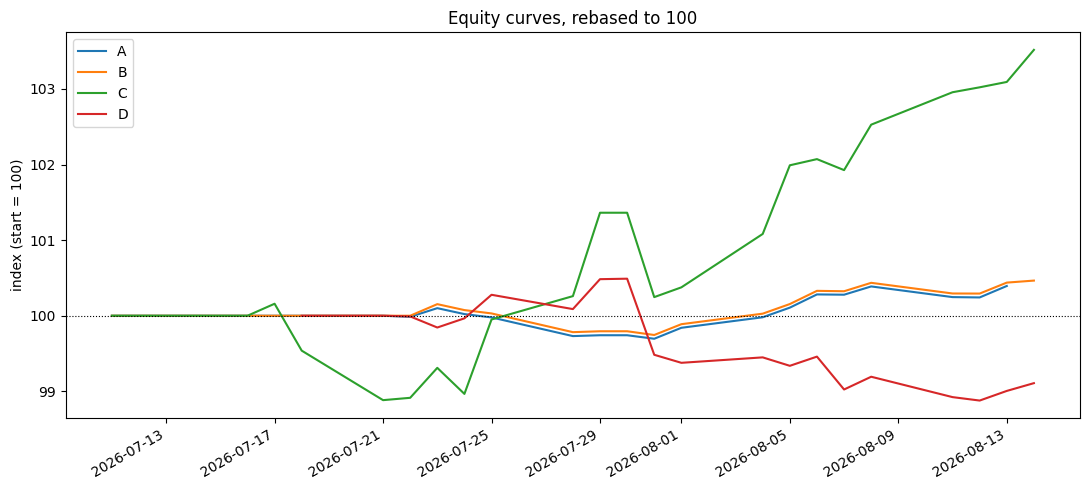

,A,B,C,D
2026-08-08,100.38758,100.43542,102.52711,99.19338
2026-08-11,100.24656,100.29440,102.95587,98.92390
2026-08-12,100.24200,100.29330,103.02097,98.87840
2026-08-13,100.39357,100.43828,103.09194,99.00582
2026-08-14,NaN,100.46490,103.51619,99.10863


In [5]:
curves = lr.equity_curves(DATA, rebased=True)
if curves.empty:
    print("No equity data yet.")
else:
    ax = curves.plot(title="Equity curves, rebased to 100")
    ax.set_ylabel("index (start = 100)"); ax.axhline(100, color="k", lw=0.8, ls=":")
    plt.tight_layout(); plt.show()
    display(curves.tail(5))

In [6]:
m = lr.metrics_table(DATA)
exp = {a: lr.exposure_series(a, DATA) for a in lr.ARMS}
m["exposure_pct"] = [
    round(float(e["exposure"].iloc[-1]) * 100, 1)
    if not e.empty and e["exposure"].notna().any() else None
    for e in exp.values()
]
m["n_positions"] = [
    int(e["n_positions"].iloc[-1]) if not e.empty else None for e in exp.values()
]
display(m)
if not m["enough_data"].all():
    print("Arms marked enough_data=False have <20 daily returns; "
          "history-dependent metrics are withheld rather than reported as noise.")

,strategy,days,return_days,current_equity,total_return_pct,cagr_pct,sharpe,sortino,max_drawdown_pct,volatility_pct,enough_data,exposure_pct,n_positions
arm,,,,,,,,,,,,,
A,parallel ensemble (champion),24,23,100393.57,0.39357,4.397647,2.720742,4.318187,-0.404185,1.586369,True,4.9,1
B,full sequential (herding contrast),25,24,100464.90,0.46490,4.990678,3.098205,4.978132,-0.407205,1.575916,True,4.9,1
C,equal-weight control (null model),25,24,103516.19,3.51619,43.743075,4.456373,7.676936,-1.272969,8.220931,True,99.2,98
D,riskbudget calm_exposure (quant),20,19,99108.63,-0.89137,NaN,NaN,NaN,NaN,NaN,False,38.8,9


Arms marked enough_data=False have <20 daily returns; history-dependent metrics are withheld rather than reported as noise.


### 1b — Halted days

Days the circuit breaker stopped an arm from trading. Flags (a position breach
too small to matter at portfolio level) are excluded — they are observations,
not interventions.

In [7]:
for arm in lr.ARMS:
    h = lr.halted_days(arm, DATA)
    print(f"Arm {arm}: {len(h)} halted day(s)" + (f" — {list(h['date'])}" if len(h) else ""))

Arm A: 0 halted day(s)
Arm B: 0 halted day(s)
Arm C: 4 halted day(s) — ['2026-07-22', '2026-07-24', '2026-07-25', '2026-07-28']
Arm D: 0 halted day(s)


## 2 — QuantStats tearsheet per arm

The full metric block renders from ~20 daily returns. The *monthly* and
*EOY* panels of `qs.reports.full` need at least two calendar months and raise
until then (`index 0 is out of bounds`), which would also abort the HTML —
so those are attempted separately and skipped cleanly while the record is short.

Saved to `data/live/reports/{arm}.html` once the full report succeeds.

**Interpretation warning.** At n ≈ 20 daily observations an annualised Sharpe
is descriptive, not inferential: its standard error is roughly √(252/n) ≈ 3.5,
so a printed Sharpe of 2.7 is not distinguishable from 0. The same applies to
CAGR extrapolated from three weeks. Read section 1's exposure column too — the
arms are not equally invested, so these numbers partly rank deployment.


Arm A: parallel ensemble (champion)  (23 return days)

Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Strategy
-------------------------  ----------
Start Period               2026-07-14
End Period                 2026-08-13
Risk-Free Rate             0.0%
Time in Market             70.0%

Cumulative Return          0.39%
CAGR﹪                     4.4%

Sharpe                     2.72
Prob. Sharpe Ratio         77.94%
Smart Sharpe               2.33
Sortino                    4.32
Smart Sortino              3.7
Sortino/√2                 3.05
Smart Sortino/√2           2.62
Omega                      1.68

Max Drawdown               -0.4%
Max DD Date                2026-07-31
Max DD Period Start        2026-07-24
Max DD Period End          2026-08-04
Longest DD Days            12
Volatility (ann.)          1.59%
Calmar                     10.88
Skew                       -0.52


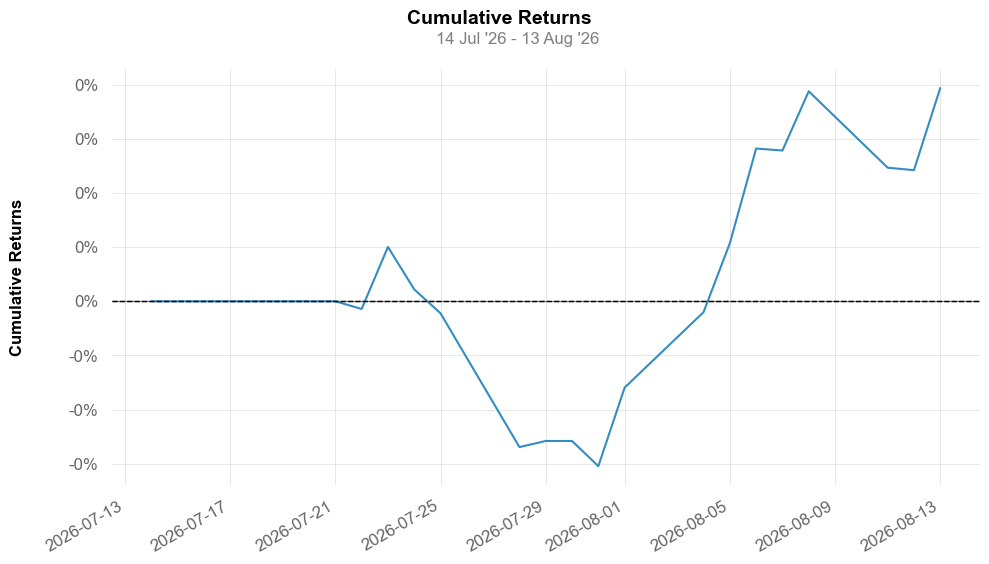

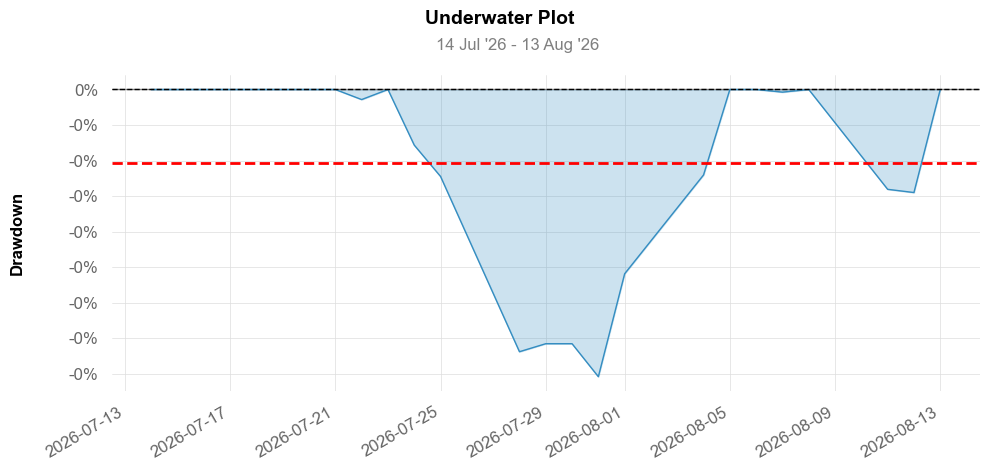

  plot 'rolling_volatility' skipped (index 0 is out of bounds for axis 0 with size 0) — needs a longer record


saved full tearsheet -> /Users/alberto/Documents/projects/HiFi/data/live/reports/A.html

Arm B: full sequential (herding contrast)  (24 return days)

Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Strategy
-------------------------  ----------
Start Period               2026-07-14
End Period                 2026-08-14
Risk-Free Rate             0.0%
Time in Market             67.0%

Cumulative Return          0.46%
CAGR﹪                     4.99%

Sharpe                     3.1
Prob. Sharpe Ratio         81.35%
Smart Sharpe               2.73
Sortino                    4.98
Smart Sortino              4.38
Sortino/√2                 3.52
Smart Sortino/√2           3.1
Omega                      1.82

Max Drawdown               -0.41%
Max DD Date                2026-07-31
Max DD Period Start        2026-07-24
Max DD Period End          2026-08-04
Longest DD Days            12
Vola

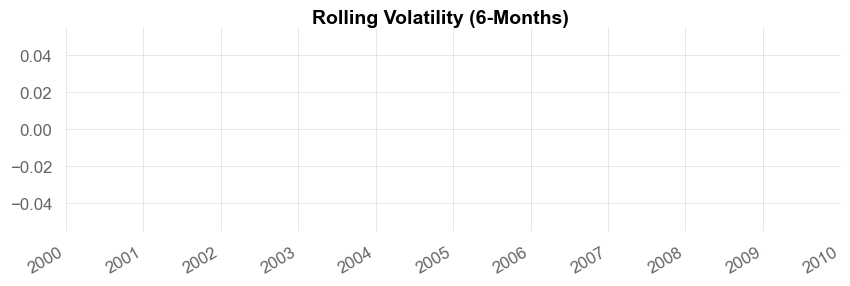

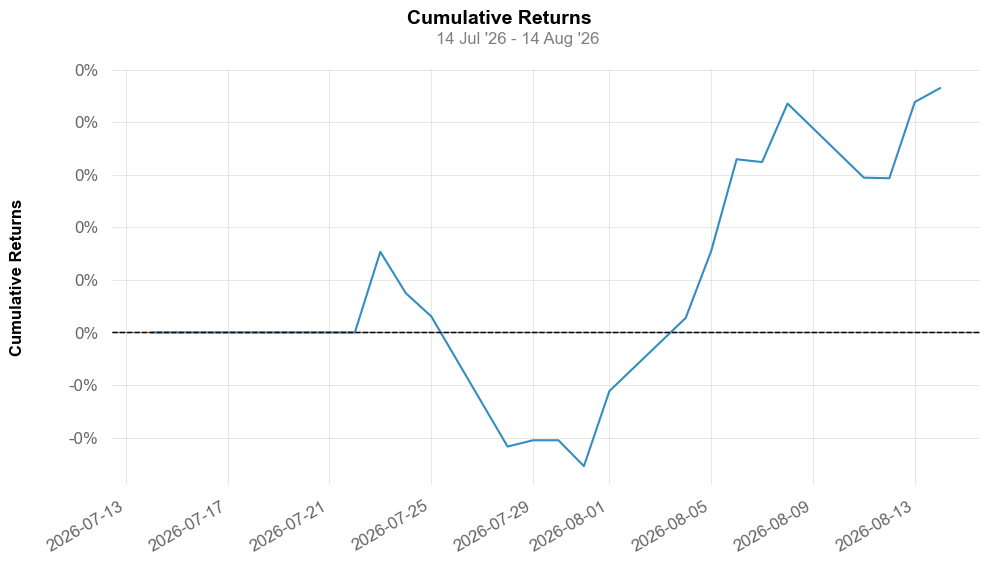

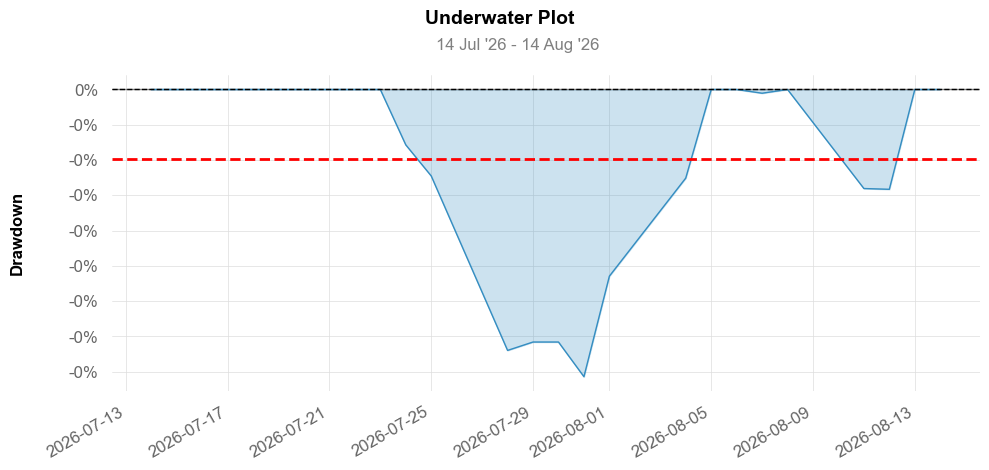

  plot 'rolling_volatility' skipped (index 0 is out of bounds for axis 0 with size 0) — needs a longer record


saved full tearsheet -> /Users/alberto/Documents/projects/HiFi/data/live/reports/B.html

Arm C: equal-weight control (null model)  (24 return days)

Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Strategy
-------------------------  ----------
Start Period               2026-07-14
End Period                 2026-08-14
Risk-Free Rate             0.0%
Time in Market             84.0%

Cumulative Return          3.52%
CAGR﹪                     43.74%

Sharpe                     4.46
Prob. Sharpe Ratio         90.34%
Smart Sharpe               3.89
Sortino                    7.68
Smart Sortino              6.7
Sortino/√2                 5.43
Smart Sortino/√2           4.74
Omega                      2.22

Max Drawdown               -1.27%
Max DD Date                2026-07-21
Max DD Period Start        2026-07-18
Max DD Period End          2026-07-25
Longest DD Days            8
Vola

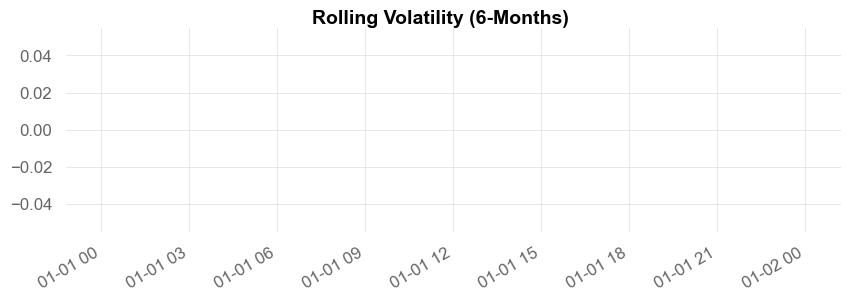

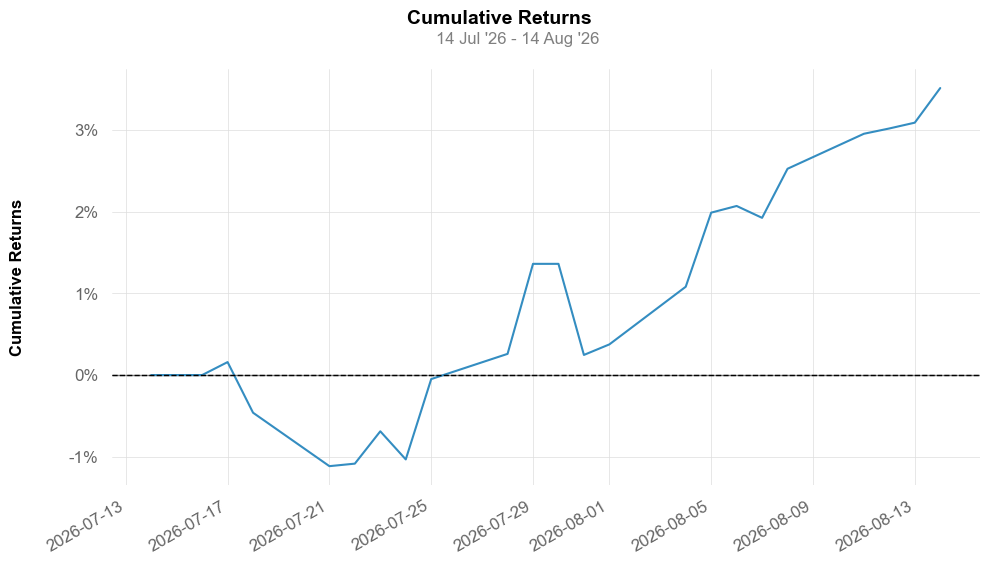

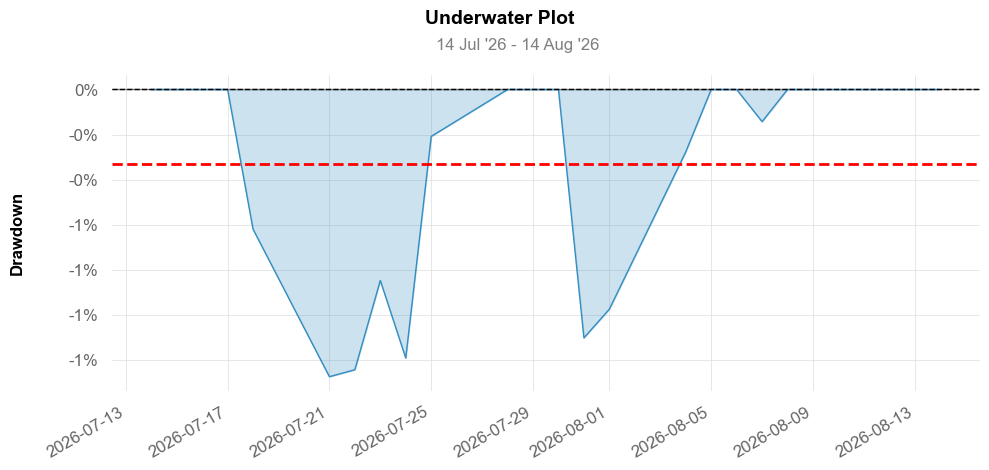

  plot 'rolling_volatility' skipped (index 0 is out of bounds for axis 0 with size 0) — needs a longer record


saved full tearsheet -> /Users/alberto/Documents/projects/HiFi/data/live/reports/C.html

Arm D: riskbudget calm_exposure (quant)  (19 return days)

Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2026-07-21
End Period           2026-08-14
Risk-Free Rate       0.0%
Time in Market       95.0%

Cumulative Return    -0.89%
CAGR﹪               -11.2%

Sharpe               -2.44
Prob. Sharpe Ratio   22.6%
Sortino              -2.78
Sortino/√2           -1.96
Omega                0.62

Max Drawdown         -1.6%
Max DD Date          2026-08-12
Max DD Period Start  2026-07-31
Max DD Period End    2026-08-14
Longest DD Days      15

Gain/Pain Ratio      -0.38
Gain/Pain (1M)       -1.0

Payoff Ratio         0.62
Profit Factor        0.62
Common Sense Ratio   0.4
CPC Index            0.19
Tail Ratio           0.65
Outlier Win Ratio    

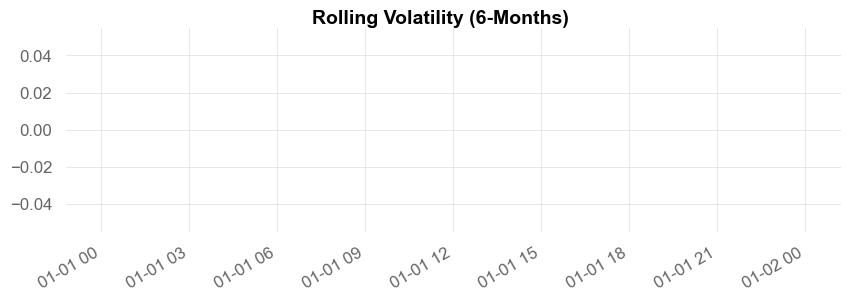

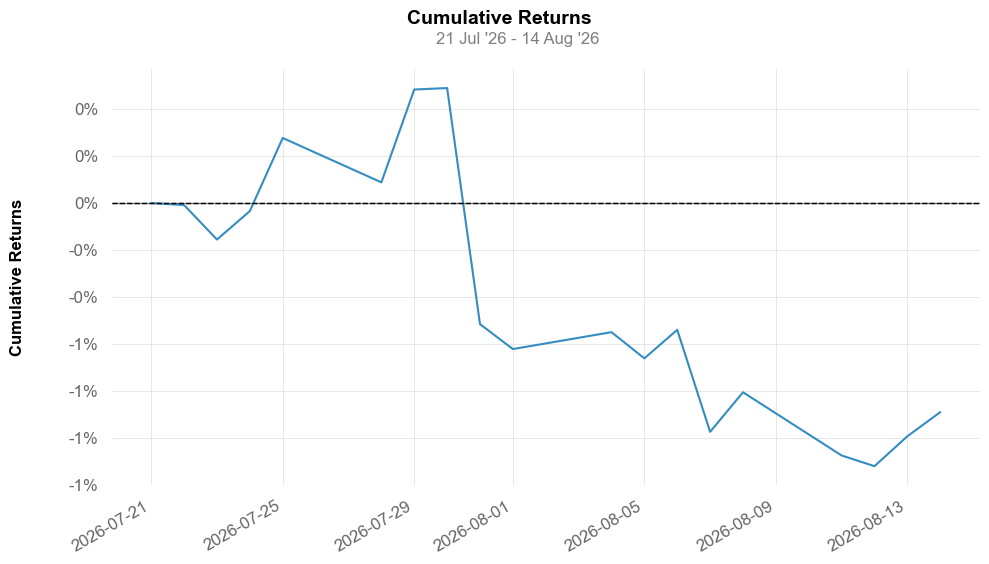

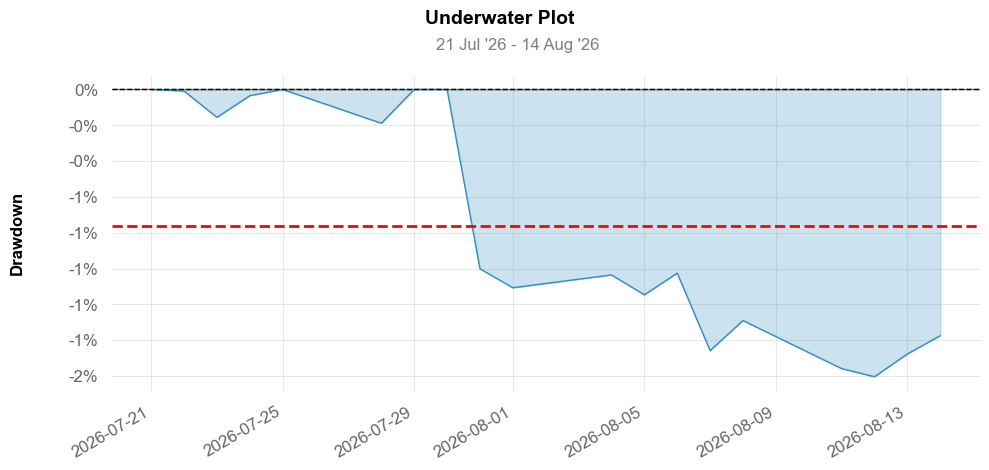

  plot 'rolling_volatility' skipped (index 0 is out of bounds for axis 0 with size 0) — needs a longer record
full HTML tearsheet pending: 19 return days across 2 calendar month(s) (needs >=20 days and >=2 months for monthly/EOY panels)


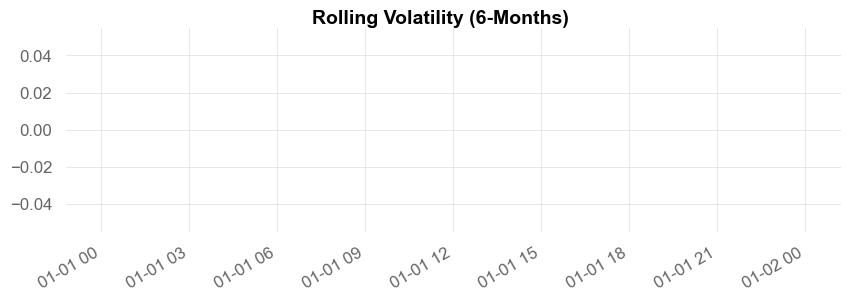

In [8]:
import quantstats as qs
MIN = 20
reports_dir = Path(DATA) / "live" / "reports"; reports_dir.mkdir(parents=True, exist_ok=True)

for arm in lr.ARMS:
    r = lr.load_returns(arm, DATA)
    label = lr.ARMS[arm]["label"]
    print(f"\n{'='*70}\nArm {arm}: {label}  ({len(r)} return days)\n{'='*70}")
    if len(r) == 0:
        print("no returns captured yet."); continue

    # 1. Metric block — works on daily data alone.
    try:
        qs.reports.metrics(r, mode="full" if len(r) >= MIN else "basic", display=True)
    except Exception as e:
        print("metrics unavailable:", e)

    # 2. Daily-only plots — the parts of the tearsheet meaningful at this length.
    # Each is attempted separately: the rolling views use a 6-month window by
    # default and raise on a record this short, which must not suppress the
    # cumulative-return and drawdown plots that do work.
    for name, fn in [("returns", qs.plots.returns),
                     ("drawdown", qs.plots.drawdown),
                     ("rolling_volatility", qs.plots.rolling_volatility)]:
        try:
            fn(r, show=True)
        except Exception as e:
            print(f"  plot '{name}' skipped ({e}) — needs a longer record")

    # 3. Full HTML tearsheet — needs >= 2 calendar months for the monthly/EOY panels.
    months = r.index.to_period("M").nunique() if len(r) else 0
    if len(r) >= MIN and months >= 2:
        try:
            out = reports_dir / f"{arm}.html"
            qs.reports.html(r, output=str(out), title=f"HiFi Arm {arm} — {label}")
            print(f"saved full tearsheet -> {out}")
        except Exception as e:
            print("html tearsheet error:", e)
    else:
        print(f"full HTML tearsheet pending: {len(r)} return days across {months} "
              f"calendar month(s) (needs >={MIN} days and >=2 months for monthly/EOY panels)")

## 3 — Decision layer

### 3a — Signal distribution over time

Each arm produces signals differently, so a blank panel is annotated rather
than left ambiguous:

- **A, B** — LLM ensemble, Buy/Hold/Sell per ticker.
- **C** — *no signal layer by design*: a buy-once-hold null model that bypasses
  the pipeline and writes `signals: []` forever. Blank here is correct.
- **D** — deterministic reason codes (section 3c).

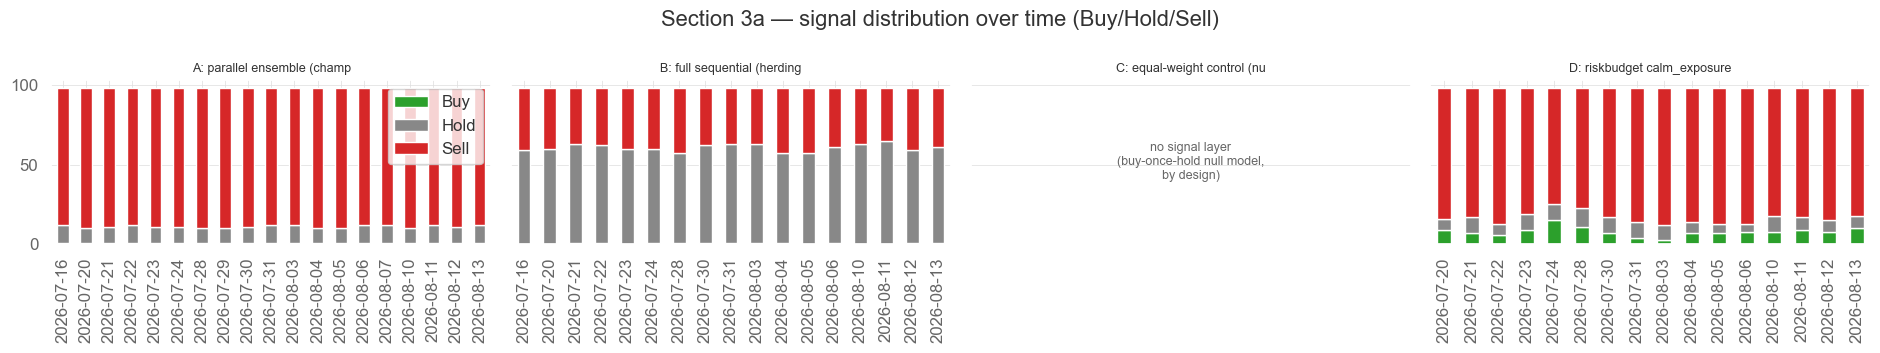

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(19, 3.6), sharey=True)
for ax, arm in zip(axes, lr.ARMS):
    kind = lr.signal_layer_kind(arm)
    sd = lr.signal_distribution(arm, DATA)
    has = not sd.empty and sd[["Buy", "Hold", "Sell"]].to_numpy().sum() > 0
    if has:
        sd.set_index("decision_date")[["Buy", "Hold", "Sell"]].plot(
            kind="bar", stacked=True, ax=ax, legend=(arm == "A"),
            color={"Buy": "#2ca02c", "Hold": "#888888", "Sell": "#d62728"})
    else:
        msg = ("no signal layer\n(buy-once-hold null model,\nby design)"
               if kind == "none-by-design" else "no signals recorded")
        ax.text(0.5, 0.5, msg, ha="center", va="center", transform=ax.transAxes,
                fontsize=9, color="#666")
        ax.set_xticks([])
    ax.set_title(f"{arm}: {lr.ARMS[arm]['label'][:24]}", fontsize=9); ax.set_xlabel("")
plt.suptitle("Section 3a — signal distribution over time (Buy/Hold/Sell)")
plt.tight_layout(); plt.show()

### 3b — Herding vs diversity (LLM arms)

`unanimity` = fraction of tickers where all agents agreed (Page-theorem
herding). `mean_entropy` = mean cross-agent disagreement entropy.

**Read against section 0c.** Unanimity requires *all* members to agree, so a
constant agent mechanically drives unanimity down — a diverse-looking arm may
simply contain a dead member. These numbers are only interpretable when no
agent is flagged constant and tool failure rates are zero.


=== Arm A (parallel ensemble (champion)) ===
decision_date  n_tickers  unanimity  mean_entropy
   2026-07-16         98        0.0      0.936457
   2026-07-20         98        0.0      0.925292
   2026-07-21         98        0.0      0.932915
   2026-07-22         98        0.0      0.931915
   2026-07-23         98        0.0      0.933915
   2026-07-24         98        0.0      0.926292
   2026-07-28         98        0.0      0.930670
   2026-07-29         98        0.0      0.927833
   2026-07-30         98        0.0      0.943079
   2026-07-31         98        0.0      0.931374
   2026-08-03         98        0.0      0.933915
   2026-08-04         98        0.0      0.937997
   2026-08-05         98        0.0      0.945620
   2026-08-06         98        0.0      0.931374
   2026-08-07         98        0.0      0.939538
   2026-08-10         98        0.0      0.922751
   2026-08-11         98        0.0      0.938998
   2026-08-12         98        0.0      0.933915
   2

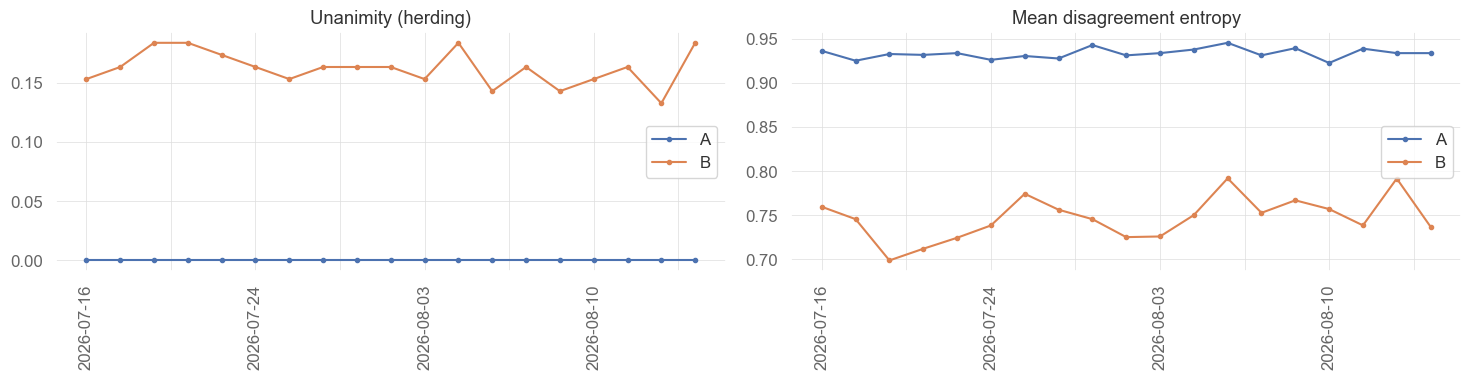

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for arm in ["A", "B"]:
    h = lr.herding_series(arm, DATA)
    if h.empty:
        print(f"Arm {arm}: no ensemble sidecars yet."); continue
    print(f"\n=== Arm {arm} ({lr.ARMS[arm]['label']}) ===")
    print(h.to_string(index=False))
    h.plot(x="decision_date", y="unanimity", ax=ax[0], marker="o", ms=3, label=arm)
    h.plot(x="decision_date", y="mean_entropy", ax=ax[1], marker="o", ms=3, label=arm)
ax[0].set_title("Unanimity (herding)"); ax[1].set_title("Mean disagreement entropy")
for a in ax:
    a.set_xlabel(""); a.tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()

### 3c — Arm D: deterministic reason codes

D is rule-based and has no ensemble, so it has no herding metric. Its `reason`
field is the deterministic analogue of the LLM rationale and belongs in the
decision layer rather than being omitted.

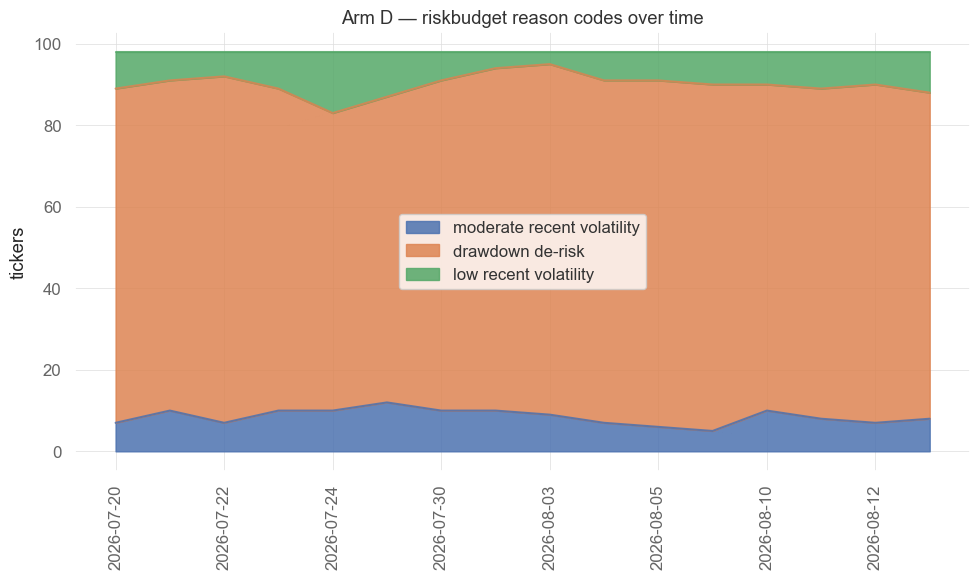

,moderate recent volatility,drawdown de-risk,low recent volatility
decision_date,,,
2026-08-03,9,86,3
2026-08-04,7,84,7
2026-08-05,6,85,7
2026-08-06,5,85,8
2026-08-10,10,80,8
2026-08-11,8,81,9
2026-08-12,7,83,8
2026-08-13,8,80,10


In [11]:
dr = lr.deterministic_reasons("D", DATA)
if dr.empty:
    print("No reason codes recorded for arm D.")
else:
    dr.plot(kind="area", stacked=True, alpha=0.85,
            title="Arm D — riskbudget reason codes over time")
    plt.ylabel("tickers"); plt.xlabel(""); plt.xticks(rotation=90)
    plt.tight_layout(); plt.show()
    display(dr.tail(8))

### 3d — Live Information Coefficient

Deferred by design: IC needs 60-trading-day forward labels (Phase 16 E3), which
do not exist for recent decisions. The report says "pending" rather than
computing a noisy proxy.

Two cautions for when it does land:

1. **Provenance.** Restrict IC to dates after the DJ-120 fix. In the Phase 15
   offline data the pre-fix IC decomposed to **−0.1377 on the 16 tickers that
   had data** and **+0.0669 on the 83 that had none** — the positive headline
   lived entirely where the agents were blind.
2. **Effective sample size.** Pairs are not independent: ~98 tickers share each
   date and 60-day forward windows overlap heavily across dates. A p-value
   computed on `n_pairs` is badly overstated; the effective n is closer to the
   number of non-overlapping dates.

In [12]:
print("Live IC:", lr.experiment_status(DATA)["ic_status"])

Live IC: pending — needs 60-day forward labels (Phase 16 E3)


## 4 — Per-stock decision traceability: why, how, when

The audit trail for a single decision. For any (arm, ticker, date):

- **why** — each agent's decision, confidence, rationale, key concern, declared data gaps
- **how** — which model, which MCP tool calls, whether they succeeded, latency
- **when** — the decision date, and whether it reached the broker as an order

Every view carries tool-call health, so a failed call can never again be
mistaken for a considered bearish opinion.

In [13]:
# Edit these three and re-run.
ARM, TICKER, DATE = "A", "ACN", None   # DATE=None -> most recent available

hist = da.ticker_history(ARM, TICKER, DATA)
if hist.empty:
    print(f"No sidecars for {ARM}/{TICKER}.")
else:
    DATE = DATE or hist["decision_date"].iloc[-1]
    print(da.format_trace(da.trace(ARM, TICKER, DATE, DATA)))

A / ACN / 2026-08-13

FUNDAMENTAL  Hold @ 0.5  [TOOL FAILURES: financial_ratios, valuation_context, macro_snapshot]
  model:   llama-3.3-70b-instruct  (39717.2 ms)
  why:     The company's revenue for the nine months ended May 31, 2026 was $55,504,334 and for the same period
         in 2025 was $52,076,717. The net income attributable to Accenture plc for the nine months
         ended May 31, 2026 was $6,375,789 and for the same period in 2025 was $6,264,470. The total
         shareholders' equity as of May 31, 2026 was $33,013,839 and as of August 31, 2025 was
         $32,240,967.
  concern: The company's ability to maintain its revenue and net income growth is a key concern, as the
         difference between the two periods is relatively small.
  gaps:    revenue_growth_yoy, earnings_growth_yoy, gross_margin, operating_margin, net_margin

TECHNICAL    Sell @ 1.0  [TOOL FAILURES: technical_indicators, risk_metrics]
  model:   Qwen2.5-Coder-32B-Instruct-MLX-8bit  (8535.2 ms)
  why

### 4b — One ticker through time

`n_tool_failures` sits beside every decision on purpose: a long run of
identical Sells with a constant non-zero failure count is a broken feed, not a
sustained view.

In [14]:
if not hist.empty:
    display(hist)
    changed = hist["ensemble"].nunique()
    print(f"{TICKER} in arm {ARM}: {len(hist)} decision days, "
          f"{changed} distinct ensemble decision(s), "
          f"{int(hist['ordered'].sum())} order(s) placed.")
    if hist["n_tool_failures"].gt(0).all():
        print("!! every decision for this ticker was made with failed tool calls "
              "— treat the whole series as uninformed")

,decision_date,ensemble,confidence,entropy,agreement,n_tool_failures,ordered,order_side,order_qty,a_fundamental,a_technical,a_risk,a_macro,a_sentiment
0,2026-07-16,Sell,0.769231,0.970951,False,7,False,None,None,Hold,Sell,Sell,Hold,Hold
1,2026-07-20,Sell,0.625000,0.721928,False,7,False,None,None,Hold,Hold,Sell,Hold,Hold
2,2026-07-21,Sell,0.769231,0.970951,False,7,False,None,None,Hold,Sell,Sell,Hold,Hold
3,2026-07-22,Sell,0.769231,0.970951,False,7,False,None,None,Hold,Sell,Sell,Hold,Hold
4,2026-07-23,Sell,0.769231,0.970951,False,7,False,None,None,Hold,Sell,Sell,Hold,Hold
5,2026-07-24,Sell,0.625000,0.721928,False,7,False,None,None,Hold,Hold,Sell,Hold,Hold
6,2026-07-28,Sell,0.769231,0.970951,False,7,False,None,None,Hold,Sell,Sell,Hold,Hold
7,2026-07-29,Sell,0.588235,0.721928,False,7,False,None,None,Hold,Hold,Sell,Hold,Hold
8,2026-07-30,Sell,0.740741,0.970951,False,7,False,None,None,Hold,Sell,Sell,Hold,Hold
9,2026-07-31,Sell,0.769231,0.970951,False,7,False,None,None,Hold,Sell,Sell,Hold,Hold


ACN in arm A: 19 decision days, 1 distinct ensemble decision(s), 0 order(s) placed.
!! every decision for this ticker was made with failed tool calls — treat the whole series as uninformed


### 4c — Why do the AI arms trade so few names?

The question this report was built to answer. Three distinct filters sit
between a universe of 98 and the orders actually placed, and they must not be
conflated:

1. **Evidence** — did the agents get data at all? (section 0)
2. **Conviction** — how many tickers did the ensemble mark Buy?
3. **Allocation** — how many Buys survived the allocator's rebalance band,
   position caps and the circuit breaker?

A small order count can come from any of the three. The table separates them.

In [15]:
rows = []
for arm in ["A", "B"]:
    sd = lr.signal_distribution(arm, DATA)
    pm = da.provenance_matrix(arm, DATA)
    if sd.empty:
        continue
    for _, r in sd.iterrows():
        d = r["decision_date"]
        day = pm[pm.decision_date == d]
        calls, failed = int(day["calls"].sum()), int(day["failed"].sum())
        rows.append({
            "arm": arm, "date": d,
            "tool_failure_rate": round(failed / calls, 3) if calls else None,
            "Buy": int(r["Buy"]), "Hold": int(r["Hold"]), "Sell": int(r["Sell"]),
            "orders": int(r["n_orders"]),
            "buys_not_ordered": int(r["Buy"]) - int(r["n_orders"]),
        })
funnel = pd.DataFrame(rows)
if funnel.empty:
    print("No signal data yet.")
else:
    display(funnel.tail(20))
    print("\nInterpretation:")
    print("  tool_failure_rate > 0  -> stage 1: the agents were blind; Buy counts are meaningless")
    print("  Buy small, failures 0  -> stage 2: a genuine AI decision to stay out")
    print("  buys_not_ordered > 0   -> stage 3: the allocator, not the LLM, suppressed the trade")

,arm,date,tool_failure_rate,Buy,Hold,Sell,orders,buys_not_ordered
16,A,2026-08-11,0.779,1,11,86,0,1
17,A,2026-08-12,0.779,1,10,87,1,0
18,A,2026-08-13,0.779,1,11,86,0,1
19,B,2026-07-16,0.779,0,59,39,0,0
20,B,2026-07-20,0.779,0,60,38,0,0
21,B,2026-07-21,0.779,1,62,35,1,0
22,B,2026-07-22,0.779,1,61,36,1,0
23,B,2026-07-23,0.779,0,60,38,0,0
24,B,2026-07-24,0.779,1,59,38,1,0
25,B,2026-07-28,0.779,1,56,41,0,1



Interpretation:
  tool_failure_rate > 0  -> stage 1: the agents were blind; Buy counts are meaningless
  Buy small, failures 0  -> stage 2: a genuine AI decision to stay out
  buys_not_ordered > 0   -> stage 3: the allocator, not the LLM, suppressed the trade


## 5 — AI-operations layer (LangFuse)

Token, latency and error telemetry per model. Requires LangFuse credentials in
`.env`; an empty table here means credentials, not an absence of activity.

In [16]:
from hifi.analytics import langfuse_report as lf
gens = lf.fetch_generations(max_items=20000)
if gens is None or gens.empty:
    print("No LangFuse telemetry (check LANGFUSE_* credentials in .env).")
else:
    print("LLM-ops summary:", lf.llm_ops_summary(gens))
    usage = lf.model_usage_table(gens)
    # Shorten filesystem-path model ids and surface unlabelled rows explicitly.
    usage.index = [str(i).split("/")[-1] if pd.notna(i) else "(unlabelled)" for i in usage.index]
    display(usage)
    broken = usage[usage["error_rate"] > 0.5]
    if len(broken):
        print("\n!! models failing >50% of calls:")
        for name, r in broken.iterrows():
            print(f"   {name}: {int(r['n_calls'])} calls, error_rate={r['error_rate']:.2f}")

LLM-ops summary: {'n_calls': 18773, 'total_tokens': 33625839, 'n_models': 7, 'mean_latency_s': 14.84, 'error_rate': 0.0074, 'first': '2026-07-14 04:26:09.660000+00:00', 'last': '2026-08-14 21:47:59.902000+00:00'}


,n_calls,total_tokens,mean_prompt_tokens,mean_completion_tokens,mean_latency_s,p95_latency_s,error_rate
llama-3.3-70b-instruct,3996,11433311,2709.0,153.0,30.50,37.56,0.0
Qwen2.5-Coder-32B-Instruct-MLX-8bit,3895,5249061,1257.0,91.0,8.74,12.05,0.0
mistral-small-3.2-24b-instruct-2506-mlx,3842,4500867,1028.0,144.0,4.26,6.74,0.0
deepseek-r1-distill-qwen-32b,3838,5998743,1056.0,507.0,17.53,23.20,0.0
mlx-qwen3.5-35b-a3b,2969,6121816,1234.0,828.0,12.87,17.82,0.0
gemma-2-2b-it,139,0,0.0,0.0,0.02,0.01,1.0
gemma-3-12b-it,91,322041,3291.0,248.0,8.52,10.22,0.0
(unlabelled),3,0,0.0,0.0,0.00,0.00,0.0



!! models failing >50% of calls:
   gemma-2-2b-it: 139 calls, error_rate=1.00


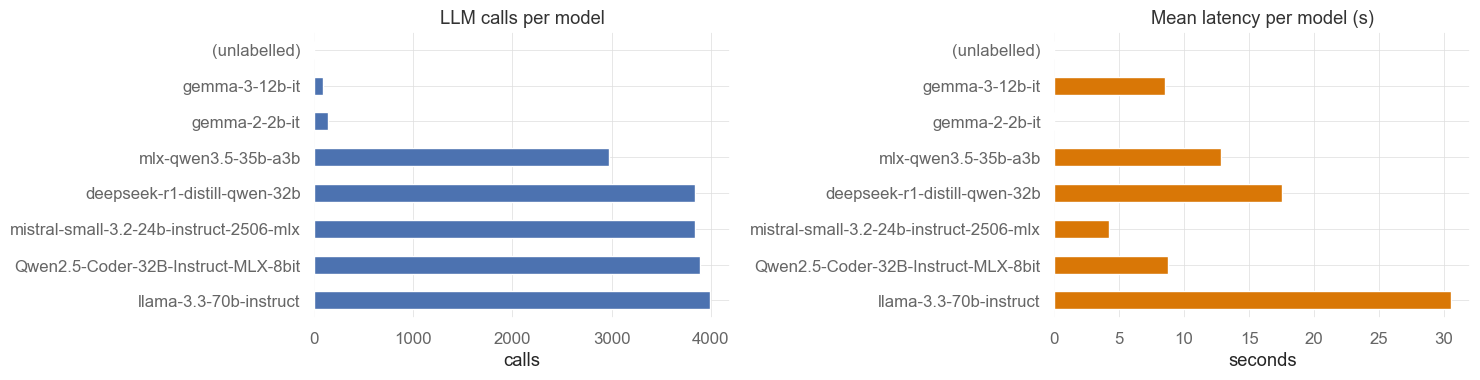

In [17]:
if gens is not None and not gens.empty:
    u = lf.model_usage_table(gens)
    u.index = [str(i).split("/")[-1] if pd.notna(i) else "(unlabelled)" for i in u.index]
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    u["n_calls"].plot(kind="barh", ax=ax[0], title="LLM calls per model")
    ax[0].set_xlabel("calls")
    u["mean_latency_s"].plot(kind="barh", ax=ax[1], color="#d97706",
                             title="Mean latency per model (s)")
    ax[1].set_xlabel("seconds")
    plt.tight_layout(); plt.show()